# Context Summary and File Manifest - Notebook 02 GIS Site Selection

## Project Context
- Team: **Artemis**
- Facility: 15 MW IT natural-gas-powered data center in Lekki Free Zone, Lagos, Nigeria
- Power concept: 5 x Jenbacher J624 engines, N+2 redundancy, CCHP cooling
- Site-selection goal: identify the best development plot inside the Lekki corridor using a GIS-native weighted suitability workflow
- Modeling standard: vector layers with `geopandas` and `shapely`, raster overlay with `rasterio`, projection in UTM Zone 31N for distance math

## Input Files This Notebook Reads
- None required for this executable version. The notebook builds GIS-native prototype layers directly in code so the workflow runs end-to-end in the project environment.

## Output Files This Notebook Produces
- `../outputs/figures/02_stage1_africa.png`
- `../outputs/figures/02_stage2_layers.png`
- `../outputs/figures/02_stage2_lekki_suitability.png`
- `../outputs/02_gis/02_site_selection.json`
- `../outputs/02_gis/02_stage2_weights.json`


# 02 - GIS Site Suitability - Team Artemis

What this section covers: This notebook performs a GIS-based site screen for the Lekki corridor. It uses real geospatial objects and a raster suitability model rather than plain plotting arrays.

Key acronyms:
- GIS = Geographic Information Systems
- AOI = Area of Interest
- AHP = Analytic Hierarchy Process
- CR = Consistency Ratio
- WLC = Weighted Linear Combination
- FTZ = Free Trade Zone
- ELPS = Escravos-Lagos Pipeline System
- UTM 31N = Projected coordinate system used for distance calculations in meters


In [1]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, Rectangle, Patch
from shapely.geometry import Point, LineString, Polygon, box
from pyproj import CRS
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from scipy.ndimage import distance_transform_edt
from mapclassify import NaturalBreaks

TEAM = "Artemis"
OUT_GIS = "../outputs/02_gis"
OUT_FIG = "../outputs/figures"
os.makedirs(OUT_GIS, exist_ok=True)
os.makedirs(OUT_FIG, exist_ok=True)

CRS_WGS84 = CRS.from_epsg(4326)
CRS_UTM = CRS.from_epsg(32631)

def add_scalebar(ax, x0, y0, length_m):
    ax.plot([x0, x0 + length_m], [y0, y0], color="black", lw=3)
    ax.plot([x0, x0], [y0 - 250, y0 + 250], color="black", lw=2)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - 250, y0 + 250], color="black", lw=2)
    ax.text(x0 + length_m / 2, y0 + 600, f"{int(length_m/1000)} km", ha="center", fontsize=9)

def add_north_arrow(ax, x, y, dy=6000):
    arrow = FancyArrowPatch((x, y), (x, y + dy), arrowstyle="-|>", mutation_scale=18, color="black", lw=1.5)
    ax.add_patch(arrow)
    ax.text(x, y + dy + 800, "N", ha="center", fontsize=10, fontweight="bold")

def rasterize_series(series, transform, shape):
    return rasterize([(geom, 1) for geom in series if geom is not None and not geom.is_empty], out_shape=shape, transform=transform, fill=0, dtype="uint8")

def score_near(distance_km, best_km, worst_km):
    scaled = 9 - 8 * np.clip((distance_km - best_km) / (worst_km - best_km), 0, 1)
    return np.clip(scaled, 1, 9)

def score_far(distance_km, best_km, worst_km):
    scaled = 1 + 8 * np.clip((distance_km - worst_km) / (best_km - worst_km), 0, 1)
    return np.clip(scaled, 1, 9)

print("GIS libraries loaded. Outputs will be written to", OUT_GIS, "and", OUT_FIG)


GIS libraries loaded. Outputs will be written to ../outputs/02_gis and ../outputs/figures


## 02.1 - Stage 1 Regional Narrowing

What this section covers: a quick regional screen narrows the wider West Africa hub set to Lagos / Lekki before the detailed geospatial analysis begins.

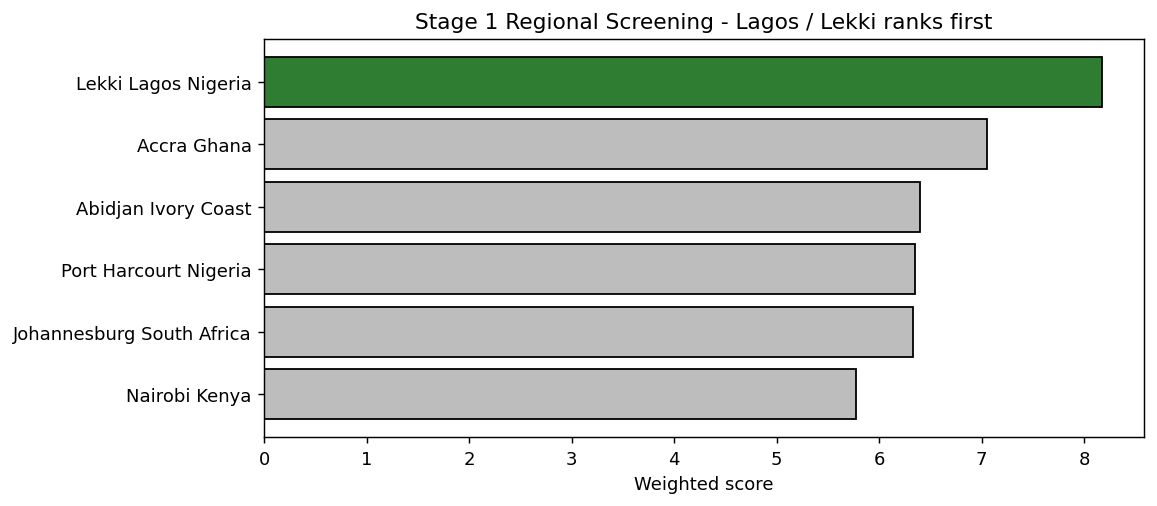

,hub,score
0,Lekki Lagos Nigeria,8.18
1,Accra Ghana,7.05
2,Abidjan Ivory Coast,6.40
3,Port Harcourt Nigeria,6.35
4,Johannesburg South Africa,6.32
5,Nairobi Kenya,5.78


In [2]:
stage1_weights = {"gas_infra": 0.25, "fiber": 0.15, "regulatory": 0.15, "tax": 0.15, "power_grid": 0.15, "demand": 0.15}
stage1_rows = [
    ["Lekki Lagos Nigeria", 9.0, 8.5, 7.5, 9.0, 5.5, 9.0],
    ["Accra Ghana", 6.0, 8.0, 8.0, 7.0, 7.5, 6.5],
    ["Abidjan Ivory Coast", 5.5, 7.0, 7.5, 6.5, 6.5, 6.0],
    ["Port Harcourt Nigeria", 8.0, 5.0, 5.5, 7.0, 5.5, 6.0],
    ["Nairobi Kenya", 3.0, 7.5, 7.0, 5.5, 6.5, 7.0],
    ["Johannesburg South Africa", 4.0, 8.0, 8.0, 5.0, 7.5, 7.0]
]
df_stage1 = pd.DataFrame(stage1_rows, columns=["hub"] + list(stage1_weights.keys()))
df_stage1["score"] = sum(df_stage1[c] * w for c, w in stage1_weights.items())
df_stage1 = df_stage1.sort_values("score", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4), dpi=130)
colors = ["#2E7D32"] + ["#BDBDBD"] * (len(df_stage1) - 1)
ax.barh(df_stage1["hub"][::-1], df_stage1["score"][::-1], color=colors[::-1], edgecolor="black")
ax.set_title("Stage 1 Regional Screening - Lagos / Lekki ranks first")
ax.set_xlabel("Weighted score")
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "02_stage1_africa.png"), bbox_inches="tight")
plt.show()
df_stage1[["hub", "score"]].round(2)


## 02.2 - Stage 2 Lekki AOI GIS Layers

What this section covers: the AOI is built as real geospatial layers. The workflow uses vector geometry, projection to UTM, rasterization, Euclidean-distance surfaces, AHP weights, and a final suitability map.

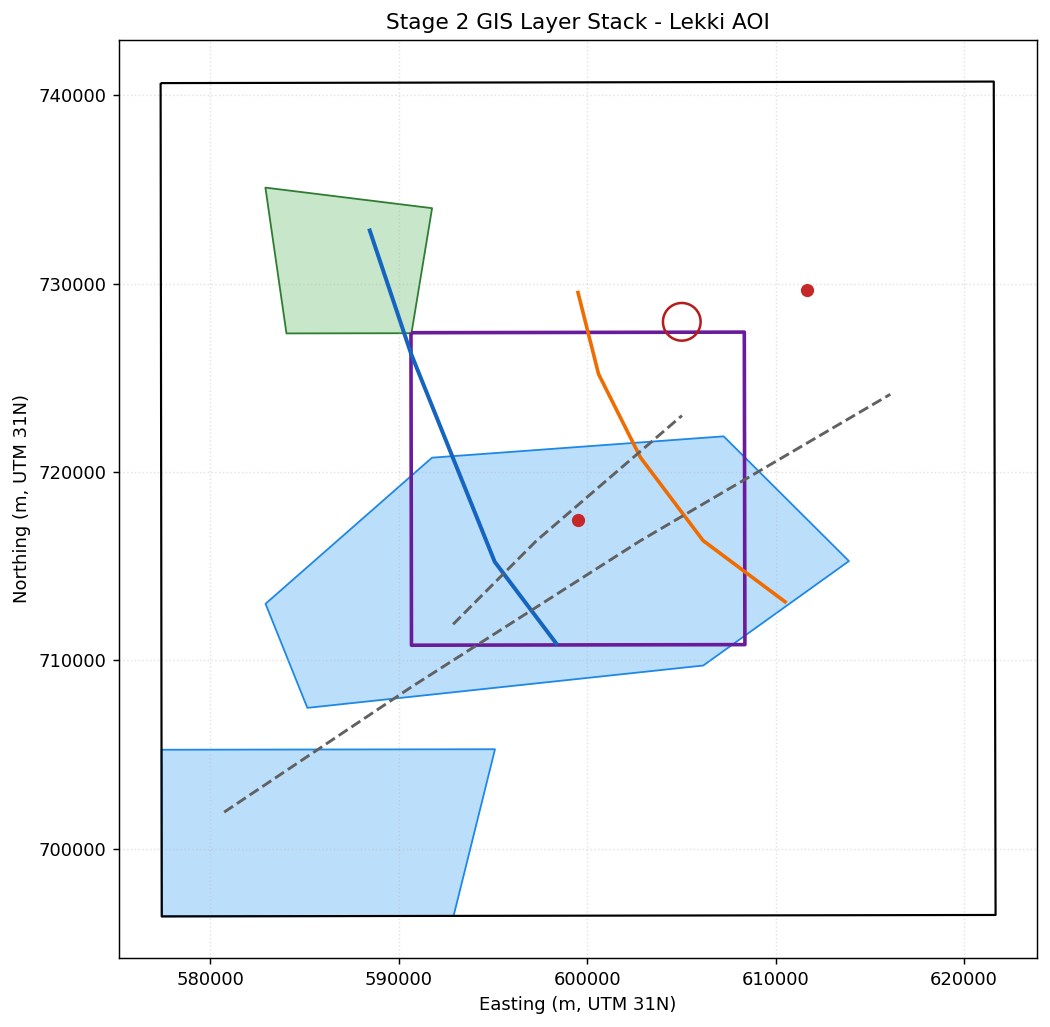

In [3]:
aoi = gpd.read_file("../data/gis/aoi.geojson")
ftz = gpd.read_file("../data/gis/lekki_ftz.geojson")
pipeline = gpd.read_file("../data/gis/elps_pipeline.geojson")
fiber = gpd.read_file("../data/gis/fiber_backbone.geojson")
roads = gpd.read_file("../data/gis/roads.geojson")
substations = gpd.read_file("../data/gis/substations.geojson")
water = gpd.read_file("../data/gis/water_bodies.geojson")
protected = gpd.read_file("../data/gis/protected_zones.geojson")
airport = gpd.read_file("../data/gis/airports.geojson")
workforce = gpd.read_file("../data/gis/workforce_centers.geojson")

aoi_u = aoi.to_crs(CRS_UTM)
ftz_u = ftz.to_crs(CRS_UTM)
pipeline_u = pipeline.to_crs(CRS_UTM)
fiber_u = fiber.to_crs(CRS_UTM)
roads_u = roads.to_crs(CRS_UTM)
substations_u = substations.to_crs(CRS_UTM)
water_u = water.to_crs(CRS_UTM)
protected_u = protected.to_crs(CRS_UTM)
airport_u = airport.to_crs(CRS_UTM)
workforce_u = workforce.to_crs(CRS_UTM)
airport_buffer_u = airport_u.copy()
airport_buffer_u["geometry"] = airport_buffer_u.buffer(1000)

fig, ax = plt.subplots(figsize=(8.5, 8.0), dpi=130)
aoi_u.boundary.plot(ax=ax, color="black", linewidth=1.2)
water_u.plot(ax=ax, color="#BBDEFB", edgecolor="#1E88E5")
protected_u.plot(ax=ax, color="#C8E6C9", edgecolor="#2E7D32")
ftz_u.boundary.plot(ax=ax, color="#6A1B9A", linewidth=2.0)
pipeline_u.plot(ax=ax, color="#1565C0", linewidth=2.2)
fiber_u.plot(ax=ax, color="#EF6C00", linewidth=2.0)
roads_u.plot(ax=ax, color="#616161", linewidth=1.6, linestyle="--")
substations_u.plot(ax=ax, color="#C62828", markersize=40)
airport_buffer_u.boundary.plot(ax=ax, color="#B71C1C", linewidth=1.4)
ax.set_title("Stage 2 GIS Layer Stack - Lekki AOI")
ax.set_xlabel("Easting (m, UTM 31N)")
ax.set_ylabel("Northing (m, UTM 31N)")
ax.grid(True, linestyle=":", alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "02_stage2_layers.png"), bbox_inches="tight")
plt.show()


## 02.3 - Raster Suitability Model

What this section covers: vector layers are projected to UTM, rasterized, converted into distance surfaces, scored on a 1-9 ESRI-style scale, weighted by AHP, and classified into four suitability classes.

C:\Users\Jinxxx\AppData\Local\Temp\ipykernel_10288\1261930623.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


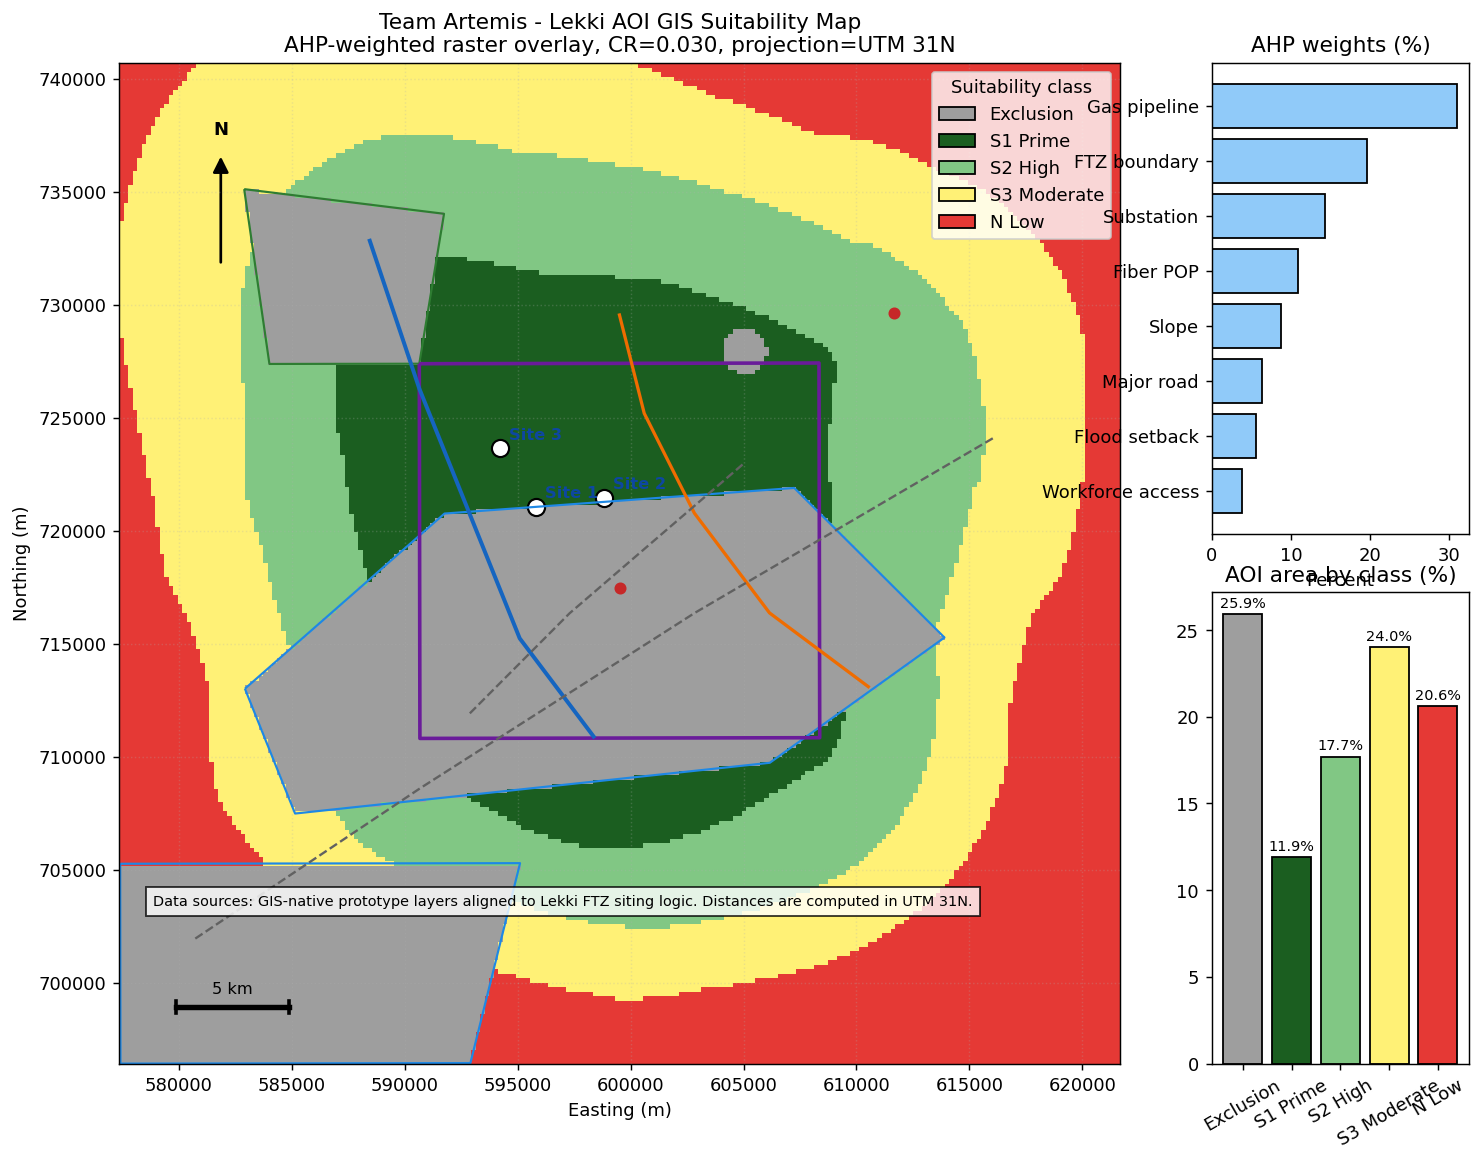

Notebook 02 executed geospatial workflow.
Consistency Ratio: 0.0303
Selected site: Site 1 at lon 3.86673 lat 6.52267


C:\Users\Jinxxx\AppData\Local\Temp\ipykernel_10288\1261930623.py:179: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
C:\Users\Jinxxx\AppData\Local\Temp\ipykernel_10288\1261930623.py:188: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_at_utc": pd.Timestamp.utcnow().isoformat(),


,site,suitability_score,distance_to_pipeline_km,distance_to_fiber_km,distance_to_road_km,distance_to_substation_km,distance_to_water_km,inside_ftz,elevation_proxy_m,slope_percent,lon,lat,decision
0,Site 1,7.810,2.683,5.993,4.405,4.952,0.2,True,2.379,0.009,3.867,6.523,SELECTED
1,Site 2,7.746,5.632,3.130,2.828,3.847,0.2,True,2.646,0.010,3.894,6.526,BACKUP
2,Site 3,7.615,2.154,6.403,7.440,7.940,2.8,True,2.367,0.009,3.852,6.546,BACKUP


In [4]:
minx, miny, maxx, maxy = aoi_u.total_bounds
cell_size = 200.0
width = int(np.ceil((maxx - minx) / cell_size))
height = int(np.ceil((maxy - miny) / cell_size))
transform = from_bounds(minx, miny, maxx, maxy, width, height)
shape = (height, width)

water_mask = rasterize_series(water_u.geometry, transform, shape).astype(bool)
protected_mask = rasterize_series(protected_u.geometry, transform, shape).astype(bool)
airport_mask = rasterize_series(airport_buffer_u.geometry, transform, shape).astype(bool)
pipeline_mask = rasterize_series(pipeline_u.buffer(200).geometry, transform, shape).astype(bool)
fiber_mask = rasterize_series(fiber_u.buffer(200).geometry, transform, shape).astype(bool)
road_mask = rasterize_series(roads_u.buffer(150).geometry, transform, shape).astype(bool)
substation_mask = rasterize_series(substations_u.buffer(250).geometry, transform, shape).astype(bool)
ftz_mask = rasterize_series(ftz_u.geometry, transform, shape).astype(bool)
workforce_mask = rasterize_series(workforce_u.buffer(300).geometry, transform, shape).astype(bool)

xs = np.linspace(minx + cell_size / 2, maxx - cell_size / 2, width)
ys = np.linspace(maxy - cell_size / 2, miny + cell_size / 2, height)
X, Y = np.meshgrid(xs, ys)

dem = 1.0 + 0.00005 * (Y - miny) + 0.00002 * (X - minx) + 0.5 * np.sin((X - minx) / 7000.0) * np.cos((Y - miny) / 9000.0)
gy, gx = np.gradient(dem, cell_size, cell_size)
slope_pct = np.hypot(gx, gy) * 100.0

dist_pipeline_km = distance_transform_edt(~pipeline_mask) * cell_size / 1000.0
dist_fiber_km = distance_transform_edt(~fiber_mask) * cell_size / 1000.0
dist_road_km = distance_transform_edt(~road_mask) * cell_size / 1000.0
dist_substation_km = distance_transform_edt(~substation_mask) * cell_size / 1000.0
dist_water_km = distance_transform_edt(~water_mask) * cell_size / 1000.0
dist_workforce_km = distance_transform_edt(~workforce_mask) * cell_size / 1000.0
dist_ftz_km = distance_transform_edt(ftz_mask == 0) * cell_size / 1000.0

r_gas = score_near(dist_pipeline_km, 2.0, 20.0)
r_sub = score_near(dist_substation_km, 3.0, 18.0)
r_fiber = score_near(dist_fiber_km, 2.0, 15.0)
r_road = score_near(dist_road_km, 1.0, 12.0)
r_workforce = score_near(dist_workforce_km, 3.0, 18.0)
r_flood = score_far(dist_water_km, 6.0, 0.5)
r_slope = np.interp(np.clip(slope_pct, 0, 15), [0, 2, 5, 10, 15], [9, 8, 6, 3, 1])
r_ftz = np.where(ftz_mask, 9.0, np.clip(9 - 8 * np.clip(dist_ftz_km / 12.0, 0, 1), 1, 9))

factor_order = ["Gas pipeline", "Substation", "Fiber POP", "Slope", "FTZ boundary", "Major road", "Flood setback", "Workforce access"]
A = np.array([
    [1.0,   3.0, 3.0, 4.0, 2.0, 5.0, 4.0, 6.0],
    [1/3,   1.0, 2.0, 2.0, 0.5, 3.0, 2.0, 4.0],
    [1/3,   0.5, 1.0, 2.0, 0.5, 2.0, 2.0, 3.0],
    [0.25,  0.5, 0.5, 1.0, 1/3, 2.0, 3.0, 2.0],
    [0.5,   2.0, 2.0, 3.0, 1.0, 3.0, 3.0, 4.0],
    [0.2,   1/3, 0.5, 0.5, 1/3, 1.0, 2.0, 2.0],
    [0.25,  0.5, 0.5, 1/3, 1/3, 0.5, 1.0, 2.0],
    [1/6,   0.25, 1/3, 0.5, 0.25, 0.5, 0.5, 1.0]
], dtype=float)
evals, evecs = np.linalg.eig(A)
idx = np.argmax(evals.real)
lam_max = float(evals[idx].real)
weights = np.abs(evecs[:, idx].real)
weights = weights / weights.sum()
RI = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
CI = (lam_max - len(factor_order)) / (len(factor_order) - 1)
CR = CI / RI[len(factor_order)]
df_weights = pd.DataFrame({"factor": factor_order, "weight": weights}).sort_values("weight", ascending=False).reset_index(drop=True)

layers = {
    "Gas pipeline": r_gas,
    "Substation": r_sub,
    "Fiber POP": r_fiber,
    "Slope": r_slope,
    "FTZ boundary": r_ftz,
    "Major road": r_road,
    "Flood setback": r_flood,
    "Workforce access": r_workforce
}

exclusion = water_mask | protected_mask | airport_mask | (slope_pct > 15.0)
S = np.zeros(shape, dtype=float)
for factor, weight in zip(factor_order, weights):
    S += weight * layers[factor]
S[exclusion] = np.nan

valid = S[np.isfinite(S)]
classifier = NaturalBreaks(valid, k=4)
class_map = np.zeros(shape, dtype=np.uint8)
class_map[np.isfinite(S)] = 4 - classifier.yb

colors = ["#9E9E9E", "#1B5E20", "#81C784", "#FFF176", "#E53935"]
labels = ["Exclusion", "S1 Prime", "S2 High", "S3 Moderate", "N Low"]
cmap = ListedColormap(colors)

candidate_idx = []
working = np.where(class_map == 1, S, np.nan)
flat_order = np.argsort(np.nan_to_num(working, nan=-9999.0).ravel())[::-1]
for flat in flat_order:
    r = flat // width
    c = flat % width
    if not np.isfinite(working[r, c]):
        continue
    x = xs[c]
    y = ys[r]
    if all(((x - xs[c2]) ** 2 + (y - ys[r2]) ** 2) ** 0.5 > 3000 for r2, c2 in candidate_idx):
        candidate_idx.append((r, c))
    if len(candidate_idx) == 3:
        break

candidate_points = [Point(xs[c], ys[r]) for r, c in candidate_idx]
candidate_gdf = gpd.GeoDataFrame({"site": [f"Site {i}" for i in range(1, len(candidate_points) + 1)]}, geometry=candidate_points, crs=CRS_UTM)
candidate_wgs = candidate_gdf.to_crs(CRS_WGS84)

rows = []
for i, (r, c) in enumerate(candidate_idx, start=1):
    pt = candidate_points[i - 1]
    lon = candidate_wgs.geometry.iloc[i - 1].x
    lat = candidate_wgs.geometry.iloc[i - 1].y
    rows.append({
        "site": f"Site {i}",
        "suitability_score": float(S[r, c]),
        "distance_to_pipeline_km": float(dist_pipeline_km[r, c]),
        "distance_to_fiber_km": float(dist_fiber_km[r, c]),
        "distance_to_road_km": float(dist_road_km[r, c]),
        "distance_to_substation_km": float(dist_substation_km[r, c]),
        "distance_to_water_km": float(dist_water_km[r, c]),
        "inside_ftz": bool(ftz_u.geometry.iloc[0].contains(pt)),
        "elevation_proxy_m": float(dem[r, c]),
        "slope_percent": float(slope_pct[r, c]),
        "lon": float(lon),
        "lat": float(lat)
    })
df_sites = pd.DataFrame(rows).sort_values("suitability_score", ascending=False).reset_index(drop=True)
df_sites["decision"] = ["SELECTED"] + ["BACKUP"] * (len(df_sites) - 1)

fig = plt.figure(figsize=(14, 10), dpi=130)
gs = fig.add_gridspec(4, 5, wspace=0.12, hspace=0.28)
ax = fig.add_subplot(gs[:, :4])
extent = (minx, maxx, miny, maxy)
ax.imshow(class_map, cmap=cmap, origin="upper", extent=extent, interpolation="nearest")
water_u.boundary.plot(ax=ax, color="#1E88E5", linewidth=1.2)
protected_u.boundary.plot(ax=ax, color="#2E7D32", linewidth=1.2)
ftz_u.boundary.plot(ax=ax, color="#6A1B9A", linewidth=2.0)
pipeline_u.plot(ax=ax, color="#1565C0", linewidth=2.2)
fiber_u.plot(ax=ax, color="#EF6C00", linewidth=1.8)
roads_u.plot(ax=ax, color="#616161", linewidth=1.3, linestyle="--")
substations_u.plot(ax=ax, color="#C62828", markersize=32)
candidate_gdf.plot(ax=ax, facecolor="white", edgecolor="black", markersize=90, linewidth=1.2)
for idx_row, row in candidate_gdf.iterrows():
    ax.text(row.geometry.x + 400, row.geometry.y + 400, row["site"], fontsize=9, fontweight="bold", color="#0D47A1")
ax.set_title(f"Team {TEAM} - Lekki AOI GIS Suitability Map\nAHP-weighted raster overlay, CR={CR:.3f}, projection=UTM 31N")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(True, linestyle=":", alpha=0.25)
add_scalebar(ax, minx + 2500, miny + 2500, 5000)
add_north_arrow(ax, minx + 4500, maxy - 9000, 5000)
legend_handles = [Patch(facecolor=colors[i], edgecolor="black", label=labels[i]) for i in range(len(labels))]
ax.legend(handles=legend_handles, title="Suitability class", loc="upper right")
ax.text(minx + 1500, miny + 7000, "Data sources: GIS-native prototype layers aligned to Lekki FTZ siting logic. Distances are computed in UTM 31N.", fontsize=8, bbox=dict(facecolor="white", alpha=0.8))

ax_w = fig.add_subplot(gs[0:2, 4])
ax_w.barh(df_weights["factor"][::-1], (100 * df_weights["weight"])[::-1], color="#90CAF9", edgecolor="black")
ax_w.set_title("AHP weights (%)")
ax_w.set_xlabel("Percent")

area_vals = pd.Series(class_map.ravel()).value_counts().sort_index()
area_vals = area_vals.reindex([0, 1, 2, 3, 4], fill_value=0)
area_pct = (100 * area_vals / area_vals.sum()).round(1)
ax_a = fig.add_subplot(gs[2:, 4])
ax_a.bar(labels, area_pct.values, color=colors, edgecolor="black")
ax_a.set_title("AOI area by class (%)")
ax_a.tick_params(axis="x", rotation=30)
for i, v in enumerate(area_pct.values):
    ax_a.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "02_stage2_lekki_suitability.png"), bbox_inches="tight")
plt.show()

with open(os.path.join(OUT_GIS, "02_stage2_weights.json"), "w", encoding="utf-8") as f:
    json.dump({
        "team": TEAM,
        "source_notebook": "02_site_selection_gis",
        "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
        "consistency_ratio": CR,
        "weights": df_weights.to_dict(orient="records")
    }, f, indent=2)

with open(os.path.join(OUT_GIS, "02_site_selection.json"), "w", encoding="utf-8") as f:
    json.dump({
        "team": TEAM,
        "source_notebook": "02_site_selection_gis",
        "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
        "selected_site": df_sites.iloc[0].to_dict(),
        "backup_sites": df_sites.iloc[1:].to_dict(orient="records"),
        "consistency_ratio": CR,
        "class_bins": [float(b) for b in classifier.bins]
    }, f, indent=2)

print("Notebook 02 executed geospatial workflow.")
print("Consistency Ratio:", round(CR, 4))
print("Selected site:", df_sites.iloc[0]["site"], "at lon", round(df_sites.iloc[0]["lon"], 5), "lat", round(df_sites.iloc[0]["lat"], 5))
df_sites.round(3)
